In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)


In [ ]:
# Compute correlation matrix
corr_matrix = df.corr()


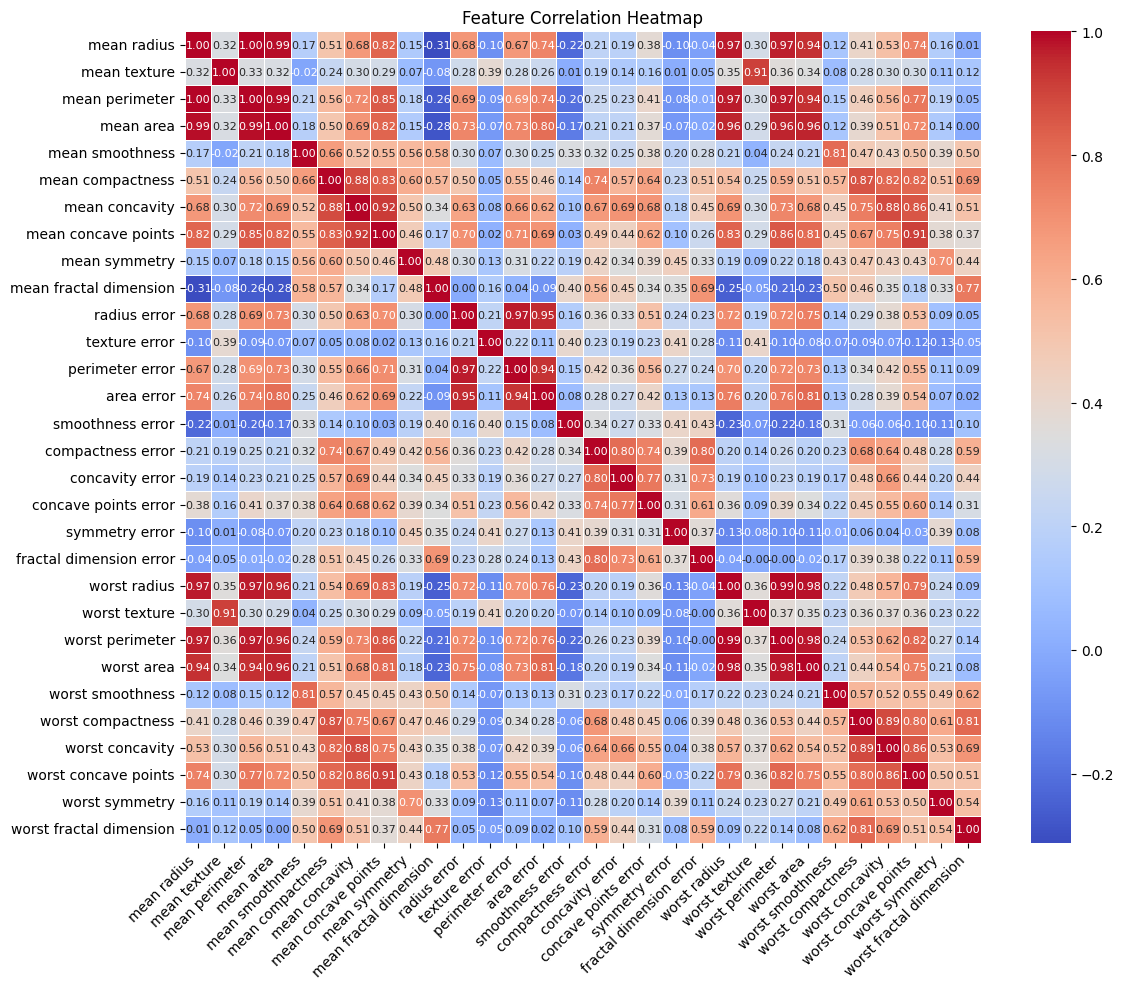

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 10))

# Create heatmap with adjusted annotation font size and label rotation
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            annot_kws={"size": 8})  # Adjust font size as needed

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Rotate y-axis labels if necessary
plt.yticks(rotation=0)

# Set title
plt.title('Feature Correlation Heatmap')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()




Train:Test = 90:10 → Accuracy: 0.9825, MSE: 0.0175, MAE: 0.0175
Train:Test = 85:15 → Accuracy: 0.9767, MSE: 0.0233, MAE: 0.0233
Train:Test = 80:20 → Accuracy: 0.9737, MSE: 0.0263, MAE: 0.0263
Train:Test = 75:25 → Accuracy: 0.9720, MSE: 0.0280, MAE: 0.0280
Train:Test = 70:30 → Accuracy: 0.9825, MSE: 0.0175, MAE: 0.0175

=== Neural Network Metrics Table ===
Train:Test  Accuracy  MSE       MAE       
90:10       0.9825    0.0175    0.0175    
85:15       0.9767    0.0233    0.0233    
80:20       0.9737    0.0263    0.0263    
75:25       0.9720    0.0280    0.0280    
70:30       0.9825    0.0175    0.0175    


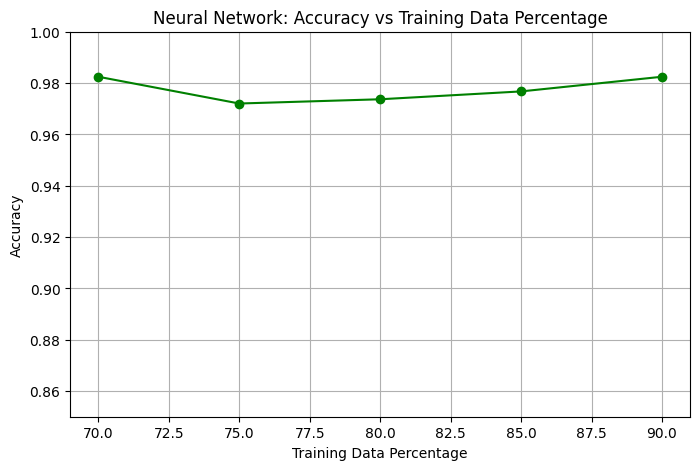

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Test splits
test_ratios = [0.1, 0.15, 0.2, 0.25, 0.3]
train_ratios = [int((1 - r) * 100) for r in test_ratios]

# Store metrics
accuracies = []
mses = []
maes = []

# Loop through splits
for test_ratio in test_ratios:
    train_ratio = int((1 - test_ratio) * 100)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=42)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Neural Network
    model = MLPClassifier(max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store
    accuracies.append(acc)
    mses.append(mse)
    maes.append(mae)

    print(f"Train:Test = {train_ratio}:{int(test_ratio*100)} → "
          f"Accuracy: {acc:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}")

# Print Table
print("\n=== Neural Network Metrics Table ===")
print(f"{'Train:Test':<12}{'Accuracy':<10}{'MSE':<10}{'MAE':<10}")
for i in range(len(train_ratios)):
    print(f"{train_ratios[i]}:{100-train_ratios[i]:<9}{accuracies[i]:<10.4f}{mses[i]:<10.4f}{maes[i]:<10.4f}")

# Plot only Accuracy vs Training %
plt.figure(figsize=(8, 5))
plt.plot(train_ratios, accuracies, marker='o', color='green')
plt.title("Neural Network: Accuracy vs Training Data Percentage")
plt.xlabel("Training Data Percentage")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(0.85, 1.0)
plt.show()


Train:Test Accuracy   MSE        MAE       
90:10      0.9298     0.0702     0.0702    
85:15      0.9419     0.0581     0.0581    
80:20      0.9474     0.0526     0.0526    
75:25      0.9580     0.0420     0.0420    
70:30      0.9591     0.0409     0.0409    


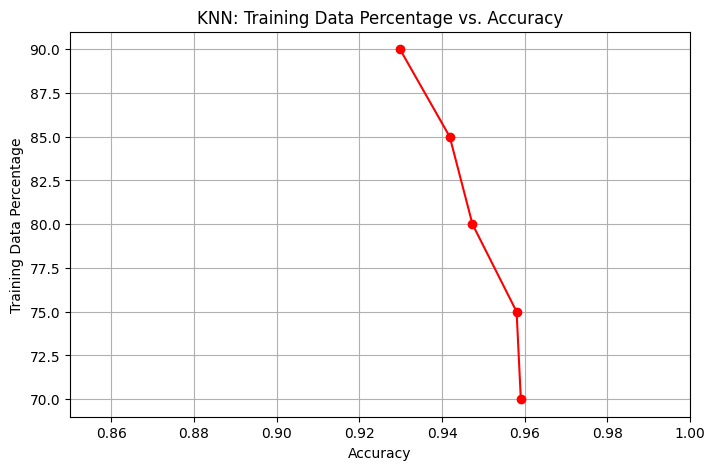

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Define test split ratios
test_ratios = [0.1, 0.15, 0.2, 0.25, 0.3]
train_ratios = [int((1 - r) * 100) for r in test_ratios]
accuracies = []
mse_values = []
mae_values = []

# Train and test KNN for each split
print("{:<10} {:<10} {:<10} {:<10}".format("Train:Test", "Accuracy", "MSE", "MAE"))
for test_ratio in test_ratios:
    train_ratio = int((1 - test_ratio) * 100)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train KNN model
    model = KNeighborsClassifier()
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    accuracies.append(acc)
    mse_values.append(mse)
    mae_values.append(mae)

    # Print row
    print("{:<10} {:<10.4f} {:<10.4f} {:<10.4f}".format(f"{train_ratio}:{int(test_ratio*100)}", acc, mse, mae))

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(accuracies, train_ratios, marker='o', color='red')
plt.title("KNN: Training Data Percentage vs. Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Training Data Percentage")
plt.grid(True)
plt.xlim(0.85, 1.0)
plt.ylim(min(train_ratios) - 1, max(train_ratios) + 1)
plt.show()


Train:Test Accuracy   MSE        MAE       
90:10      0.9649     0.0351     0.0351    
85:15      0.9767     0.0233     0.0233    
80:20      0.9825     0.0175     0.0175    
75:25      0.9720     0.0280     0.0280    
70:30      0.9766     0.0234     0.0234    


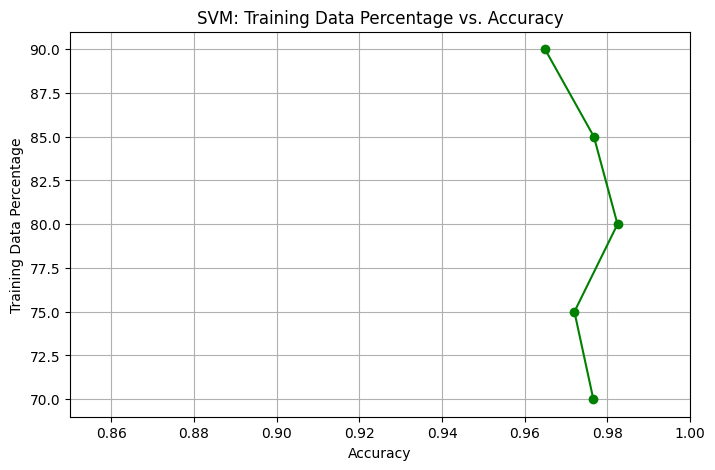

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Define test split ratios
test_ratios = [0.1, 0.15, 0.2, 0.25, 0.3]
train_ratios = [int((1 - r) * 100) for r in test_ratios]
accuracies = []
mse_values = []
mae_values = []

# Display header
print("{:<10} {:<10} {:<10} {:<10}".format("Train:Test", "Accuracy", "MSE", "MAE"))

# Train and evaluate SVM for each split
for test_ratio in test_ratios:
    train_ratio = int((1 - test_ratio) * 100)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Create and train the SVM model
    model = SVC(random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    accuracies.append(acc)
    mse_values.append(mse)
    mae_values.append(mae)

    # Print formatted results
    print("{:<10} {:<10.4f} {:<10.4f} {:<10.4f}".format(f"{train_ratio}:{int(test_ratio*100)}", acc, mse, mae))

# Plot Accuracy vs. Training Percentage
plt.figure(figsize=(8, 5))
plt.plot(accuracies, train_ratios, marker='o', color='green')
plt.title("SVM: Training Data Percentage vs. Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Training Data Percentage")
plt.grid(True)
plt.xlim(0.85, 1.0)
plt.ylim(min(train_ratios) - 1, max(train_ratios) + 1)
plt.show()


Train:Test Accuracy   MSE        MAE       
90:10      0.9649     0.0351     0.0351    
85:15      0.9535     0.0465     0.0465    
80:20      0.9649     0.0351     0.0351    
75:25      0.9650     0.0350     0.0350    
70:30      0.9708     0.0292     0.0292    


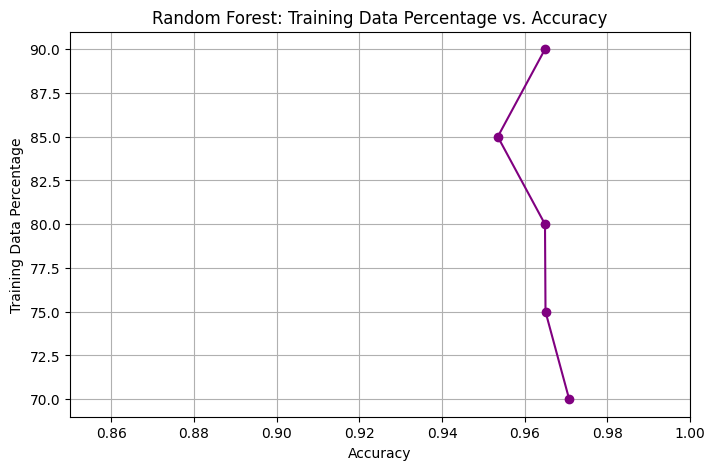

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Define test split ratios
test_ratios = [0.1, 0.15, 0.2, 0.25, 0.3]
train_ratios = [int((1 - r) * 100) for r in test_ratios]
accuracies = []
mse_values = []
mae_values = []

# Header for the table
print("{:<10} {:<10} {:<10} {:<10}".format("Train:Test", "Accuracy", "MSE", "MAE"))

# Evaluate for each split
for test_ratio in test_ratios:
    train_ratio = int((1 - test_ratio) * 100)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=42)

    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Random Forest model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predictions and metrics
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    accuracies.append(acc)
    mse_values.append(mse)
    mae_values.append(mae)

    # Print row
    print("{:<10} {:<10.4f} {:<10.4f} {:<10.4f}".format(f"{train_ratio}:{int(test_ratio*100)}", acc, mse, mae))

# Plot Accuracy vs Training Data Percentage
plt.figure(figsize=(8, 5))
plt.plot(accuracies, train_ratios, marker='o', color='purple')
plt.title("Random Forest: Training Data Percentage vs. Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Training Data Percentage")
plt.grid(True)
plt.xlim(0.85, 1.0)
plt.ylim(min(train_ratios) - 1, max(train_ratios) + 1)
plt.show()
